# 硬盘故障预警与告警分析

[English](01_disk_failure_warning_en.ipynb) · [项目说明](../README.md) · [交互看板](https://yemyu.github.io/drive-failure-warning/)

本项目用 Backblaze 每日硬盘记录生成检查名单，再回看名单中的设备是否在未来七天出现首次 `failure` 标记。每天的检查名额固定，比较逻辑回归与 SMART 非零规则能捕获多少故障事件、产生多少告警，以及能提前多久提醒。

Notebook 分两部分：先用 12 台虚构设备演示一天的特征、评分和选单过程，再读取仓库内的真实季度汇总，展示 Q3、Q4 结果与 2024 Q1 的停止原因。合成演示不参与研究结论；真实季度结果来自已完成的离线回放。

**运行**：按 [环境与快速开始](../environment/README.md) 创建环境，在仓库根目录启动 JupyterLab，打开本文件后选择 **Run → Run All Cells**。本文件不下载原始季度数据、不训练模型、不写入研究结果。

## 1. 任务、单位与时间范围

数据只包含 `ST4000DM000` 的分析结果。SMART 是设备报告的运行属性，`failure` 是 Backblaze 的运营标记，不能据此确认机械损坏原因。

| 单位 | 在这里表示什么 |
|---|---|
| 设备日 | 一台设备在一个评分日的一行输入，用于训练、评分和设备日标签评价 |
| 机会事件 | 在主事件区间内首次出现故障标记，且之前有符合协议的评分机会；一台设备的首次事件只计一次 |
| 告警 | 一次被选进检查名单的记录；同一设备可能在冷却结束后再次被选中 |

机会事件与模型分数、是否入选、是否处于冷却无关。**捕获**要求在该故障前 1–7 天至少有一次有效告警。设备日正标签数、告警命中条数和捕获事件数不能相互替代。

| 阶段 | 评分日 | 主事件区间 | 结局截止 | 用途 |
|---|---|---|---|---|
| 2023 Q1–Q2 | 01-15—06-23 | 01-22—06-24 | 06-30 | 训练与开发 |
| 2023 Q3 | 07-01—09-23 | 07-08—09-24 | 09-30 | 探索性比较 |
| 2023 Q4 | 10-01—12-24 | 10-08—12-25 | 12-31 | 固定模型时间外验证 |

Q3 曾用于输入诊断、协议修订和候选选择，因此不作为完全未见的测试集。Q4 使用已固定的模型与选单规则，没有重新训练或调参。同一设备可以跨季度出现；这是时间外验证，不是全新设备泛化测试。

In [1]:
from pathlib import Path
import csv
import datetime as dt
import html
import json
import math
import sys
from IPython.display import HTML, Image, SVG, display

LANG = 'zh'
def tr(cn, en):
    return cn if LANG == 'zh' else en

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dashboard/signal_v1/data.json').is_file()
             and (p / 'examples/small_replay/current_lr.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError(tr('请从仓库根目录或 notebooks 目录运行。',
                              'Run from the repository root or notebooks directory.'))

def read_json(relative):
    with (ROOT / relative).open(encoding='utf-8') as stream:
        return json.load(stream)

def read_csv(relative):
    with (ROOT / relative).open(newline='', encoding='utf-8') as stream:
        return list(csv.DictReader(stream))

def table(headers, rows, caption):
    esc = lambda value: html.escape(str(value))
    body = ''.join('<tr>' + ''.join('<td>' + esc(v) + '</td>' for v in row) + '</tr>'
                   for row in rows)
    title = '<caption style="text-align:left;font-weight:600;padding:8px 0">' + esc(caption) + '</caption>'
    head = '<thead><tr>' + ''.join('<th scope="col">' + esc(h) + '</th>' for h in headers) + '</tr></thead>'
    display(HTML('<div style="overflow-x:auto"><table style="border-collapse:collapse;width:100%;text-align:left">'
                 + title + head + '<tbody>' + body + '</tbody></table></div>'))

def pct(value):
    return f'{100 * float(value):.2f}%'

q3_rows = read_csv('reports/data/q3_methods.csv')
history_comparison = read_csv('reports/data/q3_history_comparison.csv')
q4 = read_json('reports/data/q4_summary.json')
diagnostics = read_json('reports/data/ml_diagnostics.json')
dashboard = read_json('dashboard/signal_v1/data.json')
model = read_json('examples/small_replay/current_lr.json')
training_config = read_json('configs/simple_baseline_v1.json')
assert len(model['features']) == 16
assert q4['opportunity_events'] == 86
table([tr('已读取的汇总', 'Loaded summary'), tr('范围', 'Scope')], [
    ['Q3', tr('6 种方法，126 个机会事件', '6 methods, 126 opportunity events')],
    ['Q4', tr('2 种方法，86 个机会事件', '2 methods, 86 opportunity events')],
    [tr('模型参数', 'Model parameters'), tr('16 个输入与固定预处理', '16 inputs and fixed preprocessing')],
], tr('仓库内输入已加载', 'Committed inputs loaded'))

已读取的汇总,范围
Q3,6 种方法，126 个机会事件
Q4,2 种方法，86 个机会事件
模型参数,16 个输入与固定预处理


## 2. 模型如何训练，名单如何产生

`current_lr` 是带 L2 正则的逻辑回归，使用 Q1–Q2 已知结局的设备日训练。训练保留全部正例，每天按固定哈希抽取约 5% 负例，用逆抽样概率权重补偿负例抽样。缺失填补均值、标准化均值和尺度只从训练数据估计，并与系数一起固定。

它使用六项当前 SMART 属性，变换后共 **16 列**，不是 16 个传感器：

| 原始属性 | 输入变换 | 列数 |
|---|---|---:|
| SMART 5、187、197、198 | `log1p(raw)`、缺失指示、非零指示 | 4 × 3 |
| SMART 9（通电时长） | `log1p(raw)`、缺失指示 | 2 |
| SMART 188 | 非零指示、缺失指示 | 2 |

缺失的数值/非零输入使用训练均值填补；缺失指示保留“原始值未报告”的信息。SMART 188 不把原始值直接当线性数值。标准化后每列与系数相乘，再加截距得到线性分数；分数越高，检查优先级越高。

评分资格要求当天有记录、最近 14 个自然日至少 12 次观测，而且当天及以前没有 `failure`。历史记录用于资格和既往故障检查；`current_lr` 的 16 列本身都是当前值变换。序列号只用于连接和稳定排序，不输入模型。

每个评分日的流程是：**截至当天的记录 → 资格检查 → 固定预处理与评分 → 排序 → 每日容量与七日冷却 → 保存名单 → 读取未来结局**。每日容量为 `ceil(N / 1000)`，其中 N 是当天所有合格设备数。模型与规则固定，最后入选设备的分数线每天会变化。

SMART 对照按 5、187、188、197、198 中非零属性的数量排序，仅从有信号的设备中选单；没有信号时不以零信号设备补满名额。两种方法分别维护冷却；一次告警后，相隔八天才可再次入选。

In [2]:
estimator = training_config['estimator']
table([tr('训练设置', 'Training setting'), tr('固定值', 'Fixed value')], [
    [tr('评分期', 'Scoring period'), '2023-01-15 — 2023-06-23'],
    [tr('未来标签截止', 'Outcome cutoff'), '2023-06-30'],
    [tr('正则', 'Regularisation'), estimator['regularization']],
    ['C', estimator['C']], ['solver', estimator['solver']],
    [tr('负例日抽样比例', 'Daily negative sampling fraction'), pct(training_config['sampling']['negative_daily_fraction'])],
    [tr('当前输入维数', 'Current-input dimensions'), len(model['features'])],
], tr('训练配置摘要；本 Notebook 不执行拟合', 'Training configuration; this notebook does not fit a model'))

训练设置,固定值
评分期,2023-01-15 — 2023-06-23
未来标签截止,2023-06-30
正则,L2
C,1.0
solver,lbfgs
负例日抽样比例,5.00%
当前输入维数,16


## 3. 合成例子：一天的记录、分数与名单

`examples/small_replay/daily.csv` 是手工构造的 **12 台虚构设备**，不是 Backblaze 样本。这里选 2023-01-22 为决策日，只把截至这一天的记录交给现有特征函数。代码复用标准库实现的独立核查函数和选单函数，避免导入完整训练或监督入口。

这是单日机制演示：起始冷却为空，不等同于从季度第一天连续回放。下一小节再人为指定一条既往告警，观察冷却如何改变名单。示例中没有训练，也不把虚构设备的捕获数加入真实结果。

In [3]:
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from pipeline.r_validation.independent_audit import _current_features, _score, _tie_break
from pipeline.replay_selection import rank_candidates, select_alerts

synthetic_rows = read_csv('examples/small_replay/daily.csv')
for row in synthetic_rows:
    row['failure'] = int(row['failure'])
    for key in row:
        if key.endswith('_raw'):
            row[key] = None if row[key] == '' else int(row[key])

decision = dt.date(2023, 1, 22)
prefix = [row for row in synthetic_rows if row['date'] <= decision.isoformat()]
assert all(row['date'] <= decision.isoformat() for row in prefix)
candidates, eligibility_rows = [], []
for serial in sorted({row['serial_number'] for row in prefix}):
    past = [row for row in prefix if row['serial_number'] == serial]
    observations = sum((decision - dt.timedelta(days=13)).isoformat() <= row['date']
                       <= decision.isoformat() for row in past)
    features = _current_features(past, decision.isoformat())
    eligibility_rows.append([serial, observations,
                             tr('是', 'yes') if any(row['failure'] for row in past) else tr('否', 'no'),
                             tr('合格', 'eligible') if features is not None else tr('不合格', 'ineligible')])
    if features is not None:
        features['score'] = _score(features, model)
        features['tie_break_sha256'] = _tie_break(decision.isoformat(), serial)
        candidates.append(features)

table([tr('虚构设备', 'Fictional drive'), tr('14 日观测数', 'Observations in 14 days'),
       tr('当天或既往故障', 'Failure today or earlier'), tr('评分资格', 'Scoring eligibility')],
      eligibility_rows, tr('2023-01-22：资格检查', '2023-01-22: eligibility'))

虚构设备,14 日观测数,当天或既往故障,评分资格
demo-A,14,否,合格
demo-B,14,否,合格
demo-C,14,是,不合格
demo-D,13,否,不合格
demo-E,12,否,不合格
demo-F,14,否,合格
demo-G,13,否,合格
demo-H,14,是,不合格
demo-I,14,否,合格
demo-J,14,否,合格


### 从当前属性到线性分数

下表展开当日排名第一的虚构设备。原始 SMART 先变成 16 列，再按随附参数标准化；“贡献”是标准化值乘系数，单位是线性分数。各贡献与截距相加，应等于现有评分函数的结果。这个算式解释模型怎么给分，不说明属性导致故障。

In [4]:
ranked = rank_candidates(candidates, 'current_lr')
example = ranked[0]
terms, feature_rows = [], []
for item in model['features']:
    raw = example[item['feature_name']]
    filled = item['imputation_mean'] if raw is None else raw
    standardised = (filled - item['standardization_mean']) / item['standardization_scale']
    contribution = standardised * item['coefficient']
    terms.append(contribution)
    feature_rows.append([item['feature_name'], '—' if raw is None else f'{raw:.5f}',
                         f'{filled:.5f}', f'{standardised:.5f}',
                         f'{item["coefficient"]:.5f}', f'{contribution:.5f}'])
reconstructed = model['intercept'] + sum(terms)
assert math.isclose(reconstructed, example['score'], rel_tol=1e-12, abs_tol=1e-12)
table([tr('输入列', 'Input column'), tr('变换后值', 'Transformed value'),
       tr('填补后值', 'After imputation'), tr('标准化值', 'Standardised value'),
       tr('系数', 'Coefficient'), tr('分数贡献', 'Score contribution')], feature_rows,
      tr('虚构设备 ' + example['serial_number'] + ' 的 16 列输入',
         '16 inputs for fictional drive ' + example['serial_number']))
table([tr('量', 'Quantity'), tr('值', 'Value')], [
    [tr('截距', 'Intercept'), f'{model["intercept"]:.6f}'],
    [tr('贡献之和', 'Sum of contributions'), f'{sum(terms):.6f}'],
    [tr('线性分数', 'Linear score'), f'{reconstructed:.6f}'],
    [tr('sigmoid 输出；未校准', 'Sigmoid output; not calibrated'), f'{1 / (1 + math.exp(-reconstructed)):.6f}'],
], tr('分数核对', 'Score reconstruction'))

输入列,变换后值,填补后值,标准化值,系数,分数贡献
smart_5_current_log1p,0.00000,0.00000,-0.10922,0.09018,-0.00985
smart_5_current_missing,0.00000,0.00000,-0.00719,0.00403,-0.00003
smart_5_current_nonzero,0.00000,0.00000,-0.12458,-0.05733,0.00714
smart_9_current_log1p,9.25961,9.25961,-21.27569,0.05710,-1.21492
smart_9_current_missing,0.00000,0.00000,-0.00719,0.00403,-0.00003
smart_187_current_log1p,1.38629,1.38629,2.28196,0.49536,1.13040
smart_187_current_missing,0.00000,0.00000,-0.00719,0.00403,-0.00003
smart_187_current_nonzero,1.00000,1.00000,3.37090,0.21991,0.74129
smart_188_current_nonzero,0.00000,0.00000,-0.11729,0.05185,-0.00608
smart_188_current_missing,0.00000,0.00000,-0.00719,0.00403,-0.00003


量,值
截距,-8.312916
贡献之和,0.630360
线性分数,-7.682556
sigmoid 输出；未校准,0.000461


### 容量、冷却与未来结局

当前合格设备数为 8，`ceil(8 / 1000) = 1`，所以只选一台。分数相同时，按固定日期与序列号哈希打破平局。下面比较“没有既往告警”和“最高分设备四天前已告警”两种明确的假设冷却状态。合成 CSV 在前面已加载；未来记录只在名单确定后用于结局展示，不进入特征或排序。这个 Notebook 没有模拟完整回放的分阶段文件访问隔离。

未来有首次故障标记时记为命中；无故障且七天均有记录时记为未命中；缺少随访且没有观察到故障时保留未知。这个单日例子只显示告警结局，不重新定义完整季度的机会事件分母。

In [5]:
scenarios = [
    (tr('无既往告警', 'No earlier alert'), {}),
    (tr('最高分设备四天前已告警', 'Top drive alerted four days ago'),
     {example['serial_number']: decision - dt.timedelta(days=4)}),
]
selection_rows = []
for label, cooldown in scenarios:
    selected, stats = select_alerts(candidates, 'current_lr', decision, dict(cooldown))
    assert stats['budget_k'] == 1
    assert len(selected) <= stats['budget_k']
    for chosen in selected:
        future = [row for row in synthetic_rows if row['serial_number'] == chosen['serial_number']
                  and decision.isoformat() < row['date']
                  <= (decision + dt.timedelta(days=7)).isoformat()]
        failures = [row['date'] for row in future if row['failure']]
        if failures:
            outcome = tr('命中', 'positive')
            lead = (dt.date.fromisoformat(min(failures)) - decision).days
        elif len({row['date'] for row in future}) == 7:
            outcome, lead = tr('未命中', 'negative'), '—'
        else:
            outcome, lead = tr('未知', 'unknown'), '—'
        selection_rows.append([label, stats['eligible_count'], stats['budget_k'],
                               stats['cooldown_excluded'], chosen['serial_number'],
                               f'{chosen["score"]:.6f}', outcome, lead])
table([tr('冷却假设', 'Cooldown assumption'), tr('合格设备数', 'Eligible drives'),
       tr('名额', 'Places'), tr('冷却排除数', 'Excluded by cooldown'),
       tr('入选设备', 'Selected drive'), tr('线性分数', 'Linear score'),
       tr('未来七日结局', 'Seven-day outcome'), tr('提前量（日）', 'Lead time (days)')],
      selection_rows, tr('合成单日名单；不是季度效能结果', 'Synthetic daily lists; not quarterly performance'))

冷却假设,合格设备数,名额,冷却排除数,入选设备,线性分数,未来七日结局,提前量（日）
无既往告警,8,1,0,demo-B,-7.682556,命中,6
最高分设备四天前已告警,8,1,1,demo-I,-8.654696,未命中,—


## 4. Q3：探索性方法比较

下面恢复真实 Q3 方法汇总。全部方法使用同一每日 0.1% 容量和七日冷却，但分数输入不同：随机与两种 SMART 规则用于对照，`age_lr` 只用通电时长；`current_lr` 用 16 列当前输入，`history_lr` 追加历史统计。AP 只在结局已知的合格设备日上计算，衡量全池排序，不是告警命中率。

方法,告警（条）,捕获/机会事件,事件召回率,未知结局告警（条）,AP（已知设备日）
random,"1,509",1/126,0.79%,8,—
smart_nonzero,"1,509",47/126,37.30%,8,0.023260
smart187,"1,509",5/126,3.97%,13,—
age_lr,"1,509",0/126,0.00%,9,0.000584
current_lr,"1,509",65/126,51.59%,11,0.119132
history_lr,"1,509",72/126,57.14%,9,0.202409


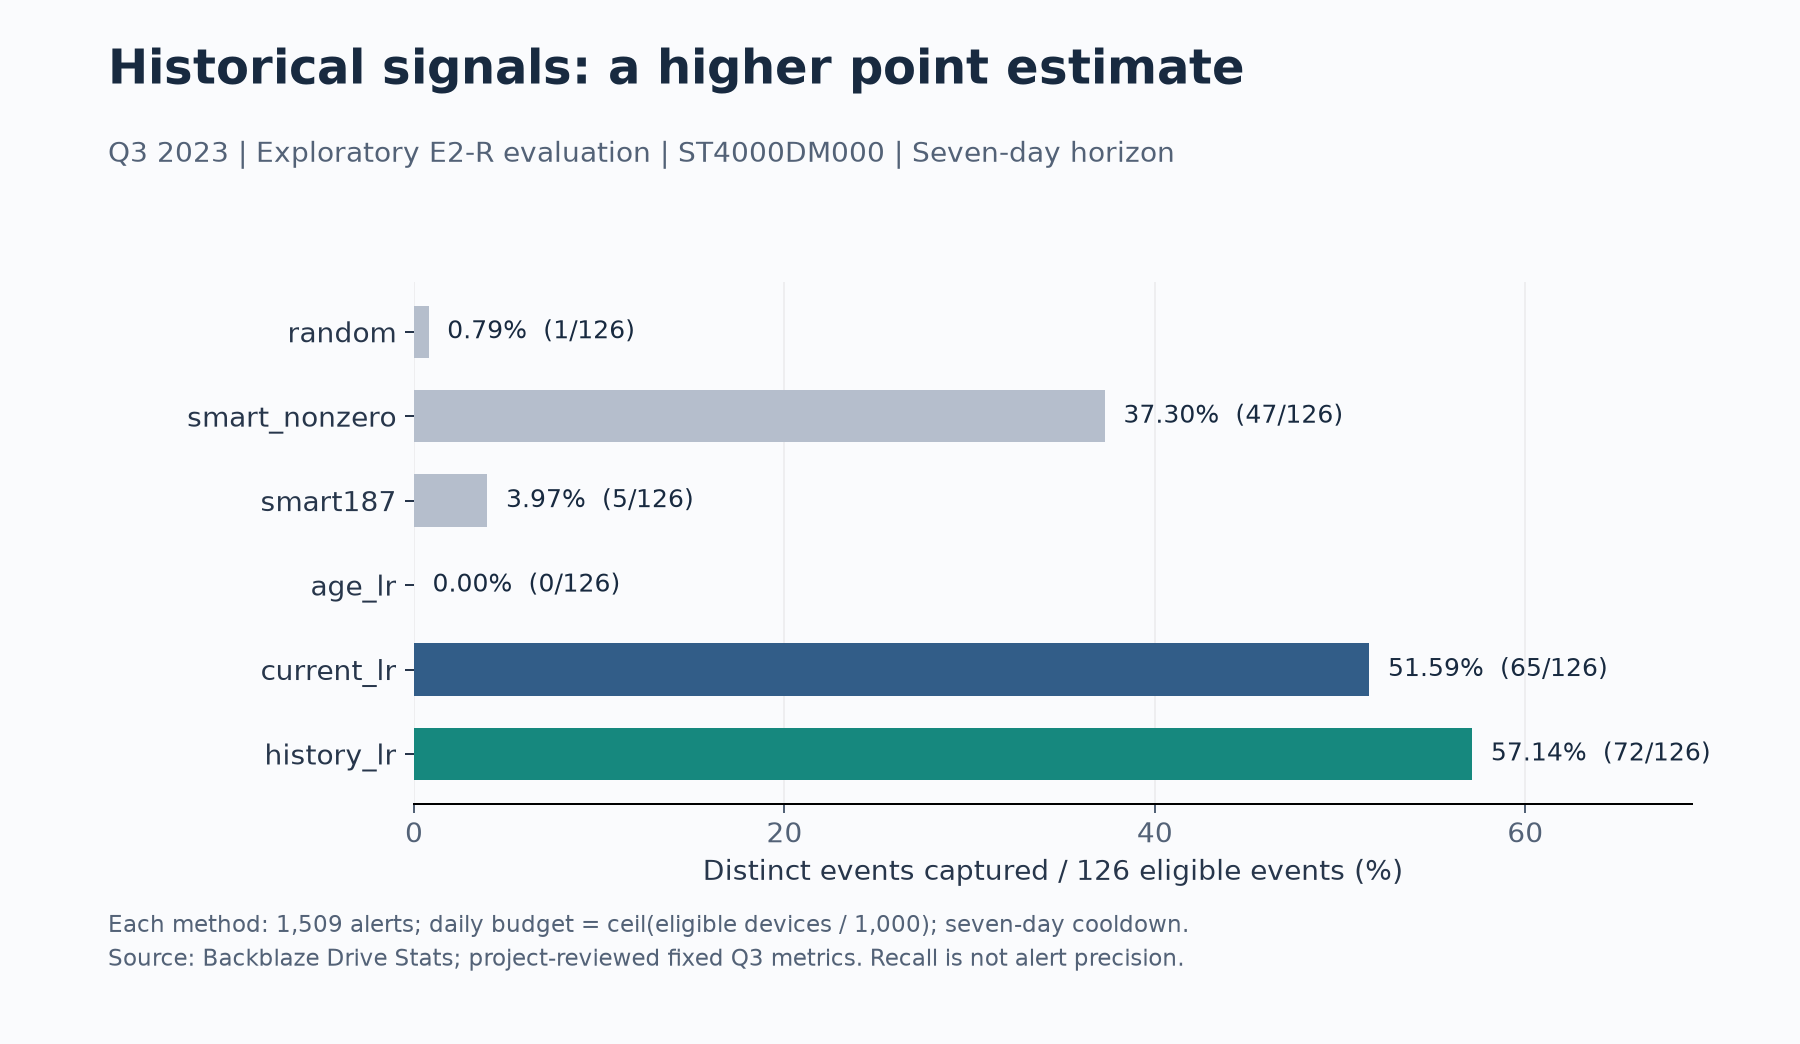

In [6]:
q3_view = []
for row in q3_rows:
    ap = float(row['average_precision_known']) if row['average_precision_known'] else None
    if row['model'] == 'smart_nonzero':
        ap = dashboard['evaluation']['q3']['smart_ap']
    q3_view.append([row['model'], f'{int(row["alerts"]):,}',
                    f'{row["event_hits"]}/{row["event_opportunity_total"]}',
                    pct(row['event_recall_at_opportunity']), row['unknown_alerts'],
                    '—' if ap is None else f'{ap:.6f}'])
table([tr('方法', 'Method'), tr('告警（条）', 'Alerts (rows)'),
       tr('捕获/机会事件', 'Captured/opportunity events'), tr('事件召回率', 'Event recall'),
       tr('未知结局告警（条）', 'Unknown alerts (rows)'), tr('AP（已知设备日）', 'AP (known device-days)')],
      q3_view, tr('2023 Q3；每日容量 0.1%', '2023 Q3; 0.1% daily capacity'))
display(Image(filename=str(ROOT / 'reports/figures/q3_event_recall.png'), width=820))

图中柱高是机会事件召回，分母均为 126；不是每日告警比例，也不是总体准确率。`current_lr` 捕获 65/126，SMART 非零规则捕获 47/126。

`history_lr` 捕获 72/126，相对当前模型多 7 个事件。设备级配对重抽的差值区间跨零，没有满足“至少增加 5 个百分点且区间下限大于零”的要求。梯度提升树在同一容量下也为 72/126，没有替换当前模型。

配对比较,点差（百分点）,95% 区间（百分点）,重抽次数
history_lr minus current_lr,5.56,-0.79 — 11.38,2000


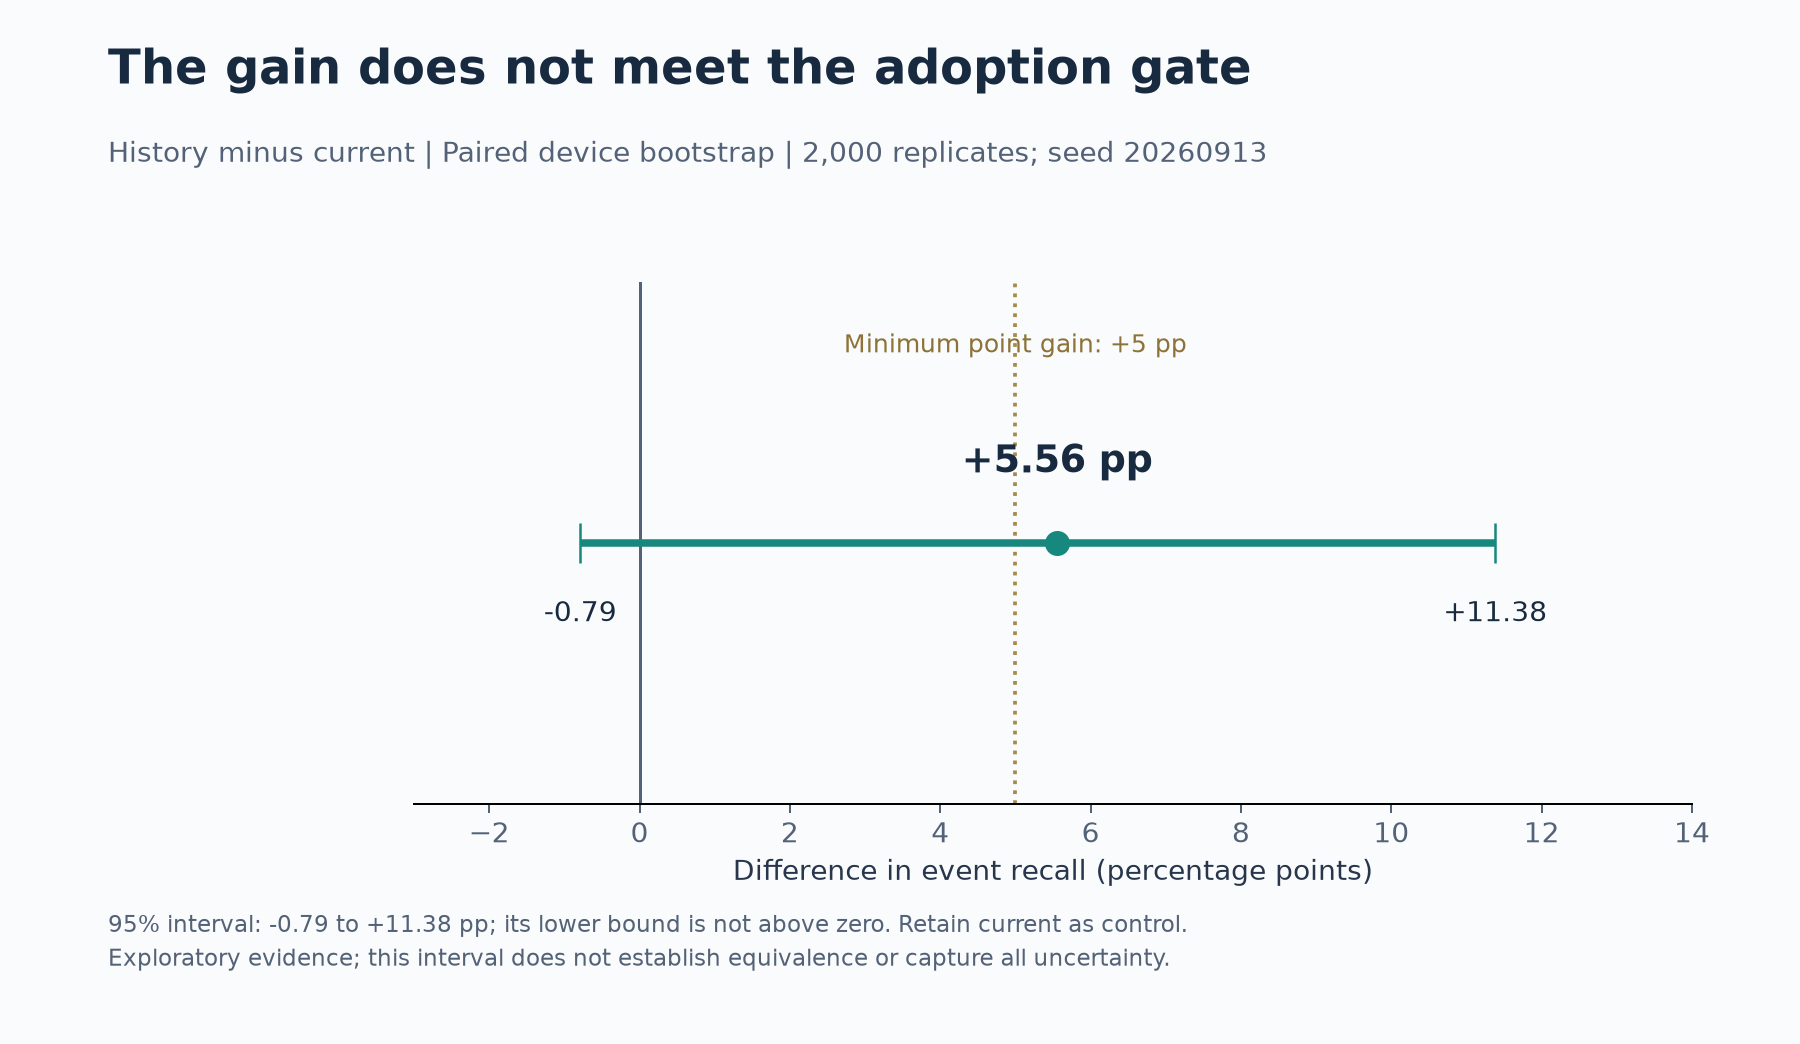

In [7]:
comparison_rows = [[row['comparison'], f'{float(row["point_difference_pp"]):.2f}',
                    f'{float(row["ci95_lower_pp"]):.2f} — {float(row["ci95_upper_pp"]):.2f}',
                    row['bootstrap_replicates']] for row in history_comparison]
table([tr('配对比较', 'Paired comparison'), tr('点差（百分点）', 'Difference (percentage points)'),
       tr('95% 区间（百分点）', '95% interval (percentage points)'), tr('重抽次数', 'Bootstrap draws')],
      comparison_rows, tr('Q3 历史特征与当前特征对照', 'Q3 historical versus current features'))
display(Image(filename=str(ROOT / 'reports/figures/q3_history_difference.png'), width=820))

## 5. Q4：固定模型时间外验证

Q4 只比较固定 `current_lr` 与 SMART 非零规则。评分覆盖 1,216,041 个合格设备日、15,976 台设备；未知评分行占 2.61%，未超过预定 20% 质量上限。下面的提前量只对已经捕获的事件计算，不能代表漏报事件。

In [8]:
q4_view = []
for name in ('current_lr', 'smart_nonzero'):
    item = q4['methods'][name]
    q4_view.append([name, f'{item["alerts"]:,}',
                    f'{item["event_hits"]}/{item["event_opportunity_total"]}',
                    pct(item['event_recall_at_opportunity']), item['unknown_alerts'],
                    f'{item["average_precision_known"]["value"]:.6f}',
                    f'{item["lead_statistics"]["median"]:.1f}'])
table([tr('方法', 'Method'), tr('告警（条）', 'Alerts (rows)'),
       tr('捕获/机会事件', 'Captured/opportunity events'), tr('事件召回率', 'Event recall'),
       tr('未知结局告警（条）', 'Unknown alerts (rows)'), tr('AP（已知设备日）', 'AP (known device-days)'),
       tr('提前量中位数（日）', 'Median lead (days)')], q4_view,
      tr('2023 Q4；每日容量 0.1%', '2023 Q4; 0.1% daily capacity'))

方法,告警（条）,捕获/机会事件,事件召回率,未知结局告警（条）,AP（已知设备日）,提前量中位数（日）
current_lr,"1,247",40/86,46.51%,38,0.082503,3.0
smart_nonzero,"1,247",35/86,40.70%,27,0.016145,2.0


`current_lr` 捕获 40/86，SMART 捕获 35/86，点差为 5.81 个百分点。但机会事件少于预先规定的 100 个，因此不发布确认性区间，差异只作描述。完成验证不等于达到了模型优于对照的证据门槛。

告警 precision 的分母是告警条数，event recall 的分母是机会事件，两个比例应分别看。未知告警不当作未命中；其上下界分别假设未知全部未命中、全部命中。

In [9]:
precision_rows = []
for name in ('current_lr', 'smart_nonzero'):
    item = q4['methods'][name]
    precision_rows.append([name, item['known_hit_alerts'], item['known_no_hit_alerts'],
                           item['unknown_alerts'], pct(item['precision']['known_outcome']),
                           pct(item['precision']['lower']) + ' — ' + pct(item['precision']['upper'])])
table([tr('方法', 'Method'), tr('已知命中（条）', 'Known positive alerts'),
       tr('已知未命中（条）', 'Known negative alerts'), tr('未知（条）', 'Unknown alerts'),
       tr('已知结局 precision', 'Precision among known outcomes'),
       tr('全告警 precision 上下界', 'Precision bounds across all alerts')], precision_rows,
      tr('Q4 告警结局；不等于捕获事件数', 'Q4 alert outcomes; distinct from captured-event counts'))

方法,已知命中（条）,已知未命中（条）,未知（条）,已知结局 precision,全告警 precision 上下界
current_lr,43,1166,38,3.56%,3.45% — 6.50%
smart_nonzero,37,1183,27,3.03%,2.97% — 5.13%


## 6. 排序表现与概率误差

AP 汇总 precision–recall 随排序阈值的变化，使用已知结局的全部合格设备日。它不同于上节固定名额下的 precision，也不同于去重事件的 recall。下图是已保存的 Q3/Q4 PR 诊断曲线；图上的设备日阈值扫描不用于重新选择告警策略。

季度,方法,AP（已知设备日）
Q3,current_lr,0.119132
Q3,smart_nonzero,0.023260
Q4,current_lr,0.082503
Q4,smart_nonzero,0.016145


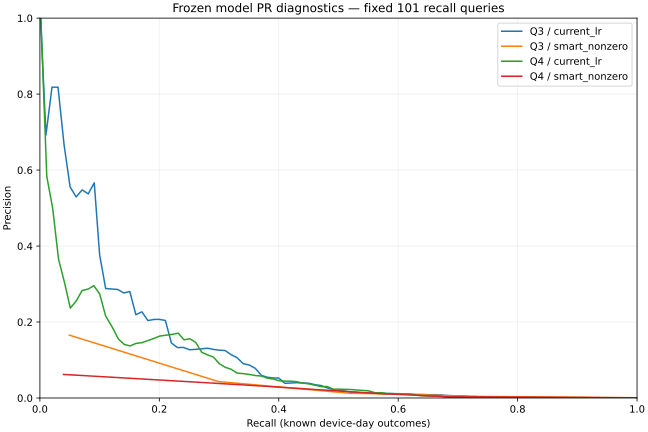

In [10]:
ranking_rows = []
for quarter in ('q3', 'q4'):
    values = dashboard['evaluation'][quarter]
    ranking_rows.extend([[quarter.upper(), 'current_lr', f'{values["lr_ap"]:.6f}'],
                         [quarter.upper(), 'smart_nonzero', f'{values["smart_ap"]:.6f}']])
table([tr('季度', 'Quarter'), tr('方法', 'Method'), tr('AP（已知设备日）', 'AP (known device-days)')],
      ranking_rows, tr('两种方法的排序表现', 'Ranking performance of both methods'))
display(SVG(filename=str(ROOT / 'reports/figures/pr_curves.svg')))

Brier score 是概率与 0/1 结局的均方误差，越低越好。SMART 非零规则是排序规则，没有提供概率，因此不把它的非零计数当概率计算 Brier。常数参照使用本季度已知结局比例，是事后诊断参照，不是可部署的预测器。

Q4 的模型 Brier 高于常数参照，预测正标签日总量约为实际的 1.81 倍。模型 AP 较高，但概率偏高；没有拟合校准器，不能把 sigmoid 输出直接解释为可信的七日故障概率。可靠性图对比每个概率区间的预测均值与观察比例；样本稀少区间只作描述，未知结局不进入比例。

季度,方法,模型 Brier,事后常数 Brier,预测/实际正标签日总量
Q3,current_lr,0.000560516,0.000598143,1.211
Q3,smart_nonzero,不适用：无概率输出,—,—
Q4,current_lr,0.000543745,0.000513939,1.807
Q4,smart_nonzero,不适用：无概率输出,—,—


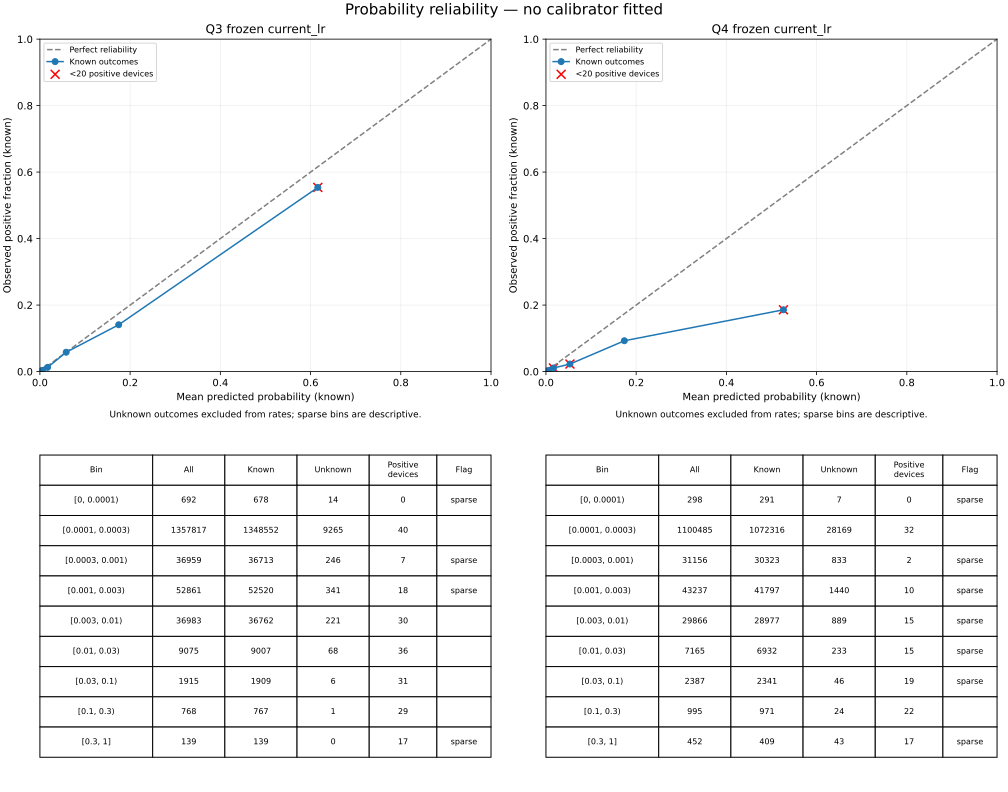

In [11]:
probability_rows = []
for quarter in ('q3', 'q4'):
    values = dashboard['evaluation'][quarter]
    probability_rows.append([quarter.upper(), 'current_lr', f'{values["brier"]:.9f}',
                             f'{values["constant_brier"]:.9f}',
                             f'{values["predicted_observed_ratio"]:.3f}'])
    probability_rows.append([quarter.upper(), 'smart_nonzero',
                             tr('不适用：无概率输出', 'Not applicable: no probability output'), '—', '—'])
table([tr('季度', 'Quarter'), tr('方法', 'Method'), tr('模型 Brier', 'Model Brier'),
       tr('事后常数 Brier', 'Retrospective constant Brier'),
       tr('预测/实际正标签日总量', 'Predicted/observed positive-label mass')], probability_rows,
      tr('概率诊断；越低的 Brier 越好', 'Probability diagnostics; lower Brier is better'))
display(SVG(filename=str(ROOT / 'reports/figures/calibration_current_lr.svg')))

## 7. 检查预算与重复提醒

Q3 有三档已完成的容量回放。容量增加会产生更多告警，但新增捕获事件不按相同比例增长。表中工时只是 `告警条数 × 假设每次检查 10 分钟` 的算术换算，没有实际人工检查记录，也不是节省成本的证据。

In [12]:
capacity_rows = []
for row in dashboard['metrics']:
    if row['model'] == 'current_lr':
        capacity_rows.append([row['capacity_label'], f'{row["alerts"]:,}',
                              f'{row["event_hits"]}/{row["opportunity_total"]}',
                              pct(row['event_recall']), pct(row['known_outcome_precision']),
                              f'{row["alerts"] * 10 / 60:.1f}'])
table([tr('每日容量', 'Daily capacity'), tr('告警（条）', 'Alerts (rows)'),
       tr('捕获/机会事件', 'Captured/opportunity events'), tr('事件召回率', 'Event recall'),
       tr('已知结局 precision', 'Precision among known outcomes'),
       tr('假设检查工时（小时）', 'Assumed inspection hours')], capacity_rows,
      tr('Q3 current_lr；每次检查假设为 10 分钟', 'Q3 current_lr; assumed 10 minutes per inspection'))

每日容量,告警（条）,捕获/机会事件,事件召回率,已知结局 precision,假设检查工时（小时）
0.05%,765,55/126,43.65%,7.35%,127.5
0.1%,"1,509",65/126,51.59%,4.41%,251.5
0.2%,"3,018",69/126,54.76%,2.34%,503.0


从 0.1% 提高到 0.2%，新增 1,509 条告警，只多捕获 4 个事件。一次设备故障可以对应多次告警，因此告警数远大于捕获事件数。下表分别列出两种方法提醒过的设备数与后续提醒条数；后续提醒不计作新的故障事件。

随后的告警结局图来自 **Q3**：显示各方法命中、未命中与未知的告警条数，不是 Q4 图，也不是故障事件数量。

季度,方法,告警（条）,收到告警的设备（台）,后续提醒（条）
Q3,current_lr,"1,509",226,"1,283"
Q3,smart_nonzero,"1,509",464,"1,045"
Q4,current_lr,"1,247",205,"1,042"
Q4,smart_nonzero,"1,247",389,858


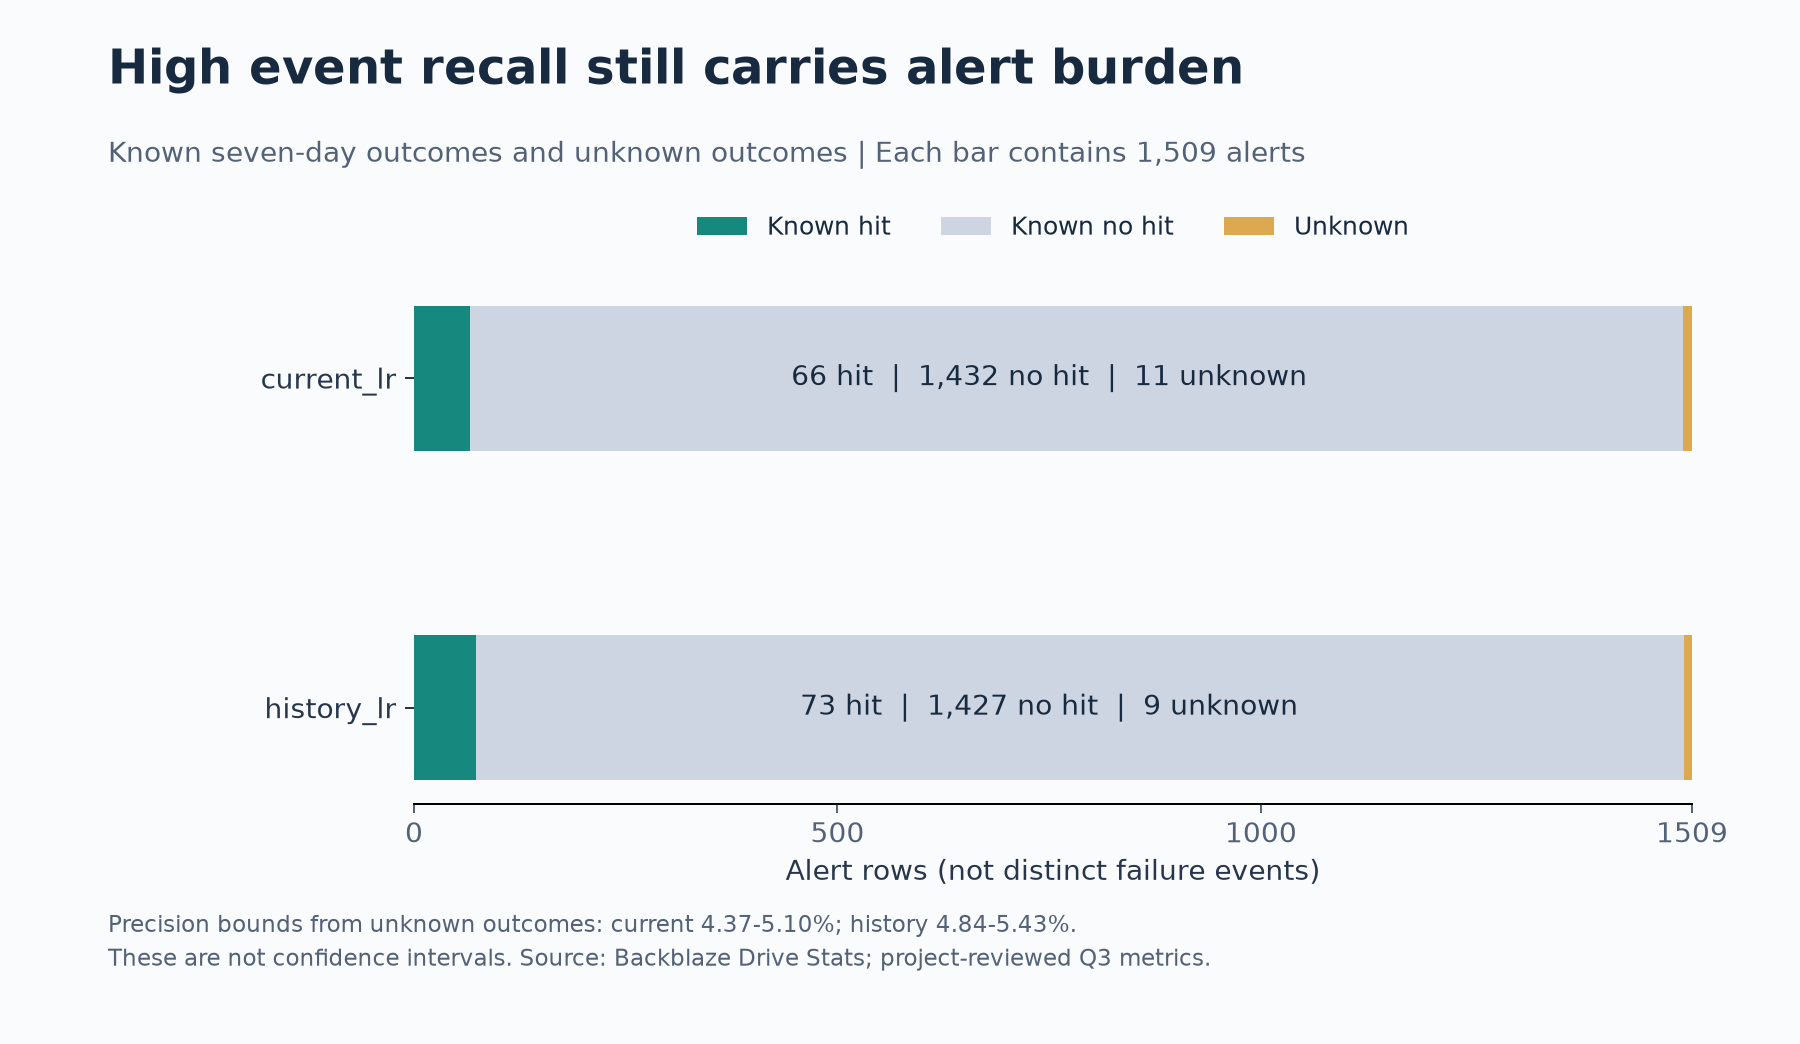

In [13]:
burden_rows = []
for quarter in ('q3', 'q4'):
    for method in ('current_lr', 'smart_nonzero'):
        item = diagnostics[quarter][method]
        burden_rows.append([quarter.upper(), method, f'{item["alerts"]:,}',
                            item['alerted_devices'], f'{item["later_alerts"]:,}'])
table([tr('季度', 'Quarter'), tr('方法', 'Method'), tr('告警（条）', 'Alerts (rows)'),
       tr('收到告警的设备（台）', 'Alerted drives'), tr('后续提醒（条）', 'Later alerts (rows)')],
      burden_rows, tr('0.1% 容量下的告警负担', 'Alert burden at 0.1% capacity'))
display(Image(filename=str(ROOT / 'reports/figures/q3_alert_outcomes.png'), width=820))

## 8. 2024 Q1：数据覆盖触发停止

2024 Q1 原计划继续比较同一固定模型与 SMART 规则。预先规则要求检查每日主型号设备数相对于前七日滚动中位数的覆盖比例。01-12 起连续三天低于 80%，01-14 为 9,034 / 11,386 = 79.34%，因此停止。

下表只读取已保存的 14 日覆盖汇总，不打开 Q1 原始数据。设备数下降的原因尚未识别，不能把它直接解释为故障、损坏文件或正常退出。Q1 没有可报告的模型效能结果，也没有为继续运行放宽停止规则。

In [14]:
coverage_rows = []
for row in dashboard['coverage'][-6:]:
    ratio = row['observed'] / row['previous_7_day_median']
    coverage_rows.append([row['date'], f'{row["observed"]:,}',
                          f'{row["previous_7_day_median"]:,}', pct(ratio),
                          row['consecutive_low']])
table([tr('日期', 'Date'), tr('观测设备（台）', 'Observed drives'),
       tr('此前七日中位数（台）', 'Previous seven-day median (drives)'),
       tr('覆盖比例', 'Coverage ratio'), tr('连续低覆盖（日）', 'Consecutive low days')],
      coverage_rows, tr('Q1 停止前的覆盖检查', 'Coverage checks before the Q1 stop'))
assert dashboard['coverage'][-1]['date'] == '2024-01-14'
assert dashboard['coverage'][-1]['consecutive_low'] == 3

日期,观测设备（台）,此前七日中位数（台）,覆盖比例,连续低覆盖（日）
2024-01-09,"11,386","11,389",99.97%,0
2024-01-10,"11,386","11,389",99.97%,0
2024-01-11,"11,384","11,389",99.96%,0
2024-01-12,"9,037","11,387",79.36%,1
2024-01-13,"9,037","11,386",79.37%,2
2024-01-14,"9,034","11,386",79.34%,3


## 9. 结论与局限

- 在同一检查容量下，当前 SMART 逻辑回归在 Q3、Q4 捕获的机会事件均多于 SMART 非零规则。Q3 属探索性比较；Q4 只有 86 个机会事件，差异仍是描述性结果。
- 历史特征与树模型没有满足替换当前模型的条件。随后在已见季度上开发的两项重复提醒降权候选，在 Q4 各捕获 43/86，比当前模型多 3 个，低于预先要求的至少 5 个，均未采纳。这是探索性重排，不是新模型的独立测试。
- AP 与固定容量召回反映排序和选单表现。概率诊断显示 Q4 预测偏高，不能将输出当作已校准风险。
- 只研究一个型号，设备可能跨期重叠；公开 `failure` 不能解释机械原因。没有真实维护干预、检查工时或节省成本的验证。2024 Q1 因覆盖规则停止，不支持延伸季度的效能结论。

数据整理、时间边界、固定模型评分、容量与冷却选单、未来结局连接共同构成离线预警流程。模型分数之外，告警能否产生有效检查机会还取决于预算、重复提醒和随访质量。

## 10. 输入文件与运行范围

本 Notebook 用 Python 标准库与 IPython 显示输出；不要求 pandas、GPU 或季度数据库。所有输入和代码都在公开仓库内。表格与模型计算可重新运行；五张图是随仓库发布的已生成图片，Notebook 不从原始设备日重画它们。

| 路径 | 用途 |
|---|---|
| `reports/data/q3_methods.csv` | Q3 六方法结果 |
| `reports/data/q3_history_comparison.csv` | 历史/当前模型配对差值 |
| `reports/data/q4_summary.json` | Q4 结果与 precision 上下界 |
| `reports/data/ml_diagnostics.json` | Q3/Q4 设备与重复提醒汇总 |
| `dashboard/signal_v1/data.json` | AP、Brier、容量、候选与覆盖汇总 |
| `examples/small_replay/daily.csv` | 12 台虚构设备的记录 |
| `examples/small_replay/current_lr.json` | 16 列预处理参数、系数与截距 |
| `configs/simple_baseline_v1.json` | 固定训练设置 |
| `pipeline/r_validation/independent_audit.py` | 当前特征与分数核查函数 |
| `pipeline/replay_selection.py` | 排序、容量与冷却函数 |
| `reports/figures/q3_event_recall.png` | Q3 方法召回图 |
| `reports/figures/q3_history_difference.png` | Q3 配对差值图 |
| `reports/figures/q3_alert_outcomes.png` | Q3 告警结局图 |
| `reports/figures/pr_curves.svg` | Q3/Q4 PR 诊断图 |
| `reports/figures/calibration_current_lr.svg` | Q3/Q4 概率可靠性图 |

完整原始数据、训练结果数据库与执行证据不随精简仓库发布。**运行本文件不是从原始 CSV 重建完整研究。** [小规模回放](../examples/small_replay/README.md)提供更长的合成执行示例；完整回放入口目前限支持的 POSIX 环境，不能据此声称已在 Windows 验证。本 Notebook 没有导入该入口。

继续阅读：[Q3 研究说明](../reports/Q3_RESEARCH_RESULT_BRIEF.md) · [Q4 验证报告](../reports/R_VALIDATION_RESULTS.md) · [机器学习诊断](../reports/ML_EVALUATION_DIAGNOSTICS.md) · [方法与评价口径](../reports/METHODS.md)。Backblaze 原始数据与使用条件见 [Hard Drive Test Data](https://www.backblaze.com/cloud-storage/resources/hard-drive-test-data)。